In [ ]:
# ================================
# PROYECTO FINAL IA
# Predicción de abandono estudiantil
# ================================

print("Proyecto final de Inteligencia Artificial")
print("Tema: Predicción de abandono estudiantil con Machine Learning y recomendaciones con LLM")

Proyecto final de Inteligencia Artificial
Tema: Predicción de abandono estudiantil con Machine Learning y recomendaciones con LLM


In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Cargar dataset desde UCI
dataset = fetch_ucirepo(id=697)

# Separar variables predictoras y variable objetivo
X = dataset.data.features
y = dataset.data.targets

# Unir todo en un solo DataFrame para explorarlo mejor
df = pd.concat([X, y], axis=1)

# Mostrar primeras filas
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
print("Filas y columnas del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

Filas y columnas del dataset:
(4424, 37)

Columnas:
Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units

In [ ]:
df["Target"].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
df["Target"].value_counts(normalize=True) * 100

,proportion
Target,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


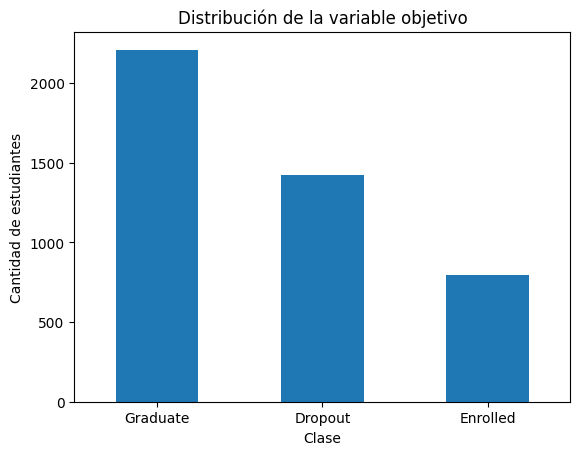

In [ ]:
import matplotlib.pyplot as plt

df["Target"].value_counts().plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=0)
plt.show()

## Descripción del problema

El objetivo del proyecto es construir un sistema de inteligencia artificial capaz de predecir el estado académico final de un estudiante: abandono, matrícula activa o graduación. Para esto se utiliza un dataset de educación superior con información académica, demográfica y socioeconómica de los estudiantes.

El problema se aborda como una tarea de clasificación multiclase, donde el modelo debe aprender patrones asociados al abandono estudiantil y al éxito académico. Adicionalmente, el sistema generará recomendaciones personalizadas para estudiantes en riesgo usando un componente basado en LLM.

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [ ]:
# Crear una variable binaria para predecir abandono
# 1 = Dropout
# 0 = Graduate o Enrolled

df["Dropout_Binary"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

df[["Target", "Dropout_Binary"]].head()

,Target,Dropout_Binary
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


In [ ]:
df["Dropout_Binary"].value_counts()

,count
Dropout_Binary,
0,3003
1,1421


In [ ]:
df["Dropout_Binary"].value_counts(normalize=True) * 100

,proportion
Dropout_Binary,
0,67.879747
1,32.120253


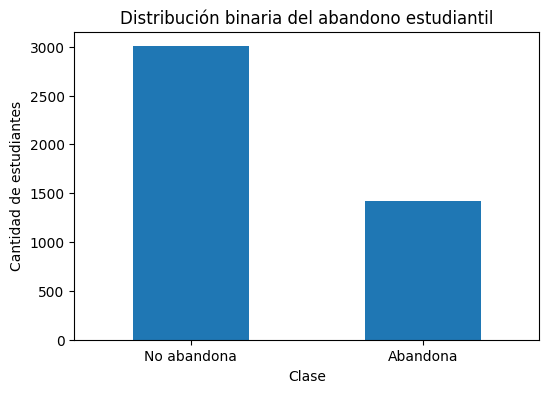

In [ ]:
import matplotlib.pyplot as plt

conteo_abandono = df["Dropout_Binary"].value_counts().sort_index()

plt.figure(figsize=(6,4))
conteo_abandono.plot(kind="bar")

plt.title("Distribución binaria del abandono estudiantil")
plt.xlabel("Clase")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(ticks=[0, 1], labels=["No abandona", "Abandona"], rotation=0)
plt.show()

### Distribución de la variable objetivo

La variable objetivo original del dataset contiene tres clases: Graduate, Dropout y Enrolled. Para este proyecto se transformó en una variable binaria llamada `Dropout_Binary`, donde 1 representa a los estudiantes que abandonaron y 0 representa a los estudiantes graduados o aún matriculados.

Esta transformación permite abordar el problema como una tarea de clasificación binaria enfocada en detectar estudiantes en riesgo de abandono. Se observa que existe una proporción considerable de estudiantes que abandonaron, lo cual justifica el desarrollo de un modelo predictivo para apoyar procesos de intervención temprana.

In [ ]:
# Revisar valores nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]

,0


In [ ]:
print("Cantidad total de valores nulos en el dataset:", df.isnull().sum().sum())

Cantidad total de valores nulos en el dataset: 0


### Valores nulos

Se realizó una revisión de valores faltantes en todas las variables del dataset. No se encontraron valores nulos, por lo que no fue necesario aplicar técnicas de imputación. Esto facilita el proceso de preprocesamiento y reduce el riesgo de introducir sesgos por reemplazo artificial de datos.

In [ ]:
# Mostrar todas las columnas del dataset
for col in df.columns:
    print(col)

Marital Status
Application mode
Application order
Course
Daytime/evening attendance
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
Curricular units 1st sem (credited)
Curricular units 1st sem (enrolled)
Curricular units 1st sem (evaluations)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (credited)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (evaluations)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP
Target
Dropout_Binary


In [ ]:
columnas_interes = [
    "Admission grade",
    "Previous qualification (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Age at enrollment",
    "Tuition fees up to date",
    "Debtor",
    "Scholarship holder"
]

# Filtrar solo las columnas que existan en el dataset
columnas_interes = [col for col in columnas_interes if col in df.columns]

df.groupby("Dropout_Binary")[columnas_interes].mean().T

Dropout_Binary,0,1
Admission grade,127.932434,124.961365
Previous qualification (grade),133.322744,131.114075
Curricular units 1st sem (approved),5.726274,2.551724
Curricular units 1st sem (grade),12.242187,7.256656
Curricular units 2nd sem (approved),5.616717,1.940183
Curricular units 2nd sem (grade),12.279544,5.899339
Age at enrollment,21.938395,26.068966
Tuition fees up to date,0.976357,0.678395
Debtor,0.063603,0.219564
Scholarship holder,0.321345,0.094300


<Figure size 600x400 with 0 Axes>

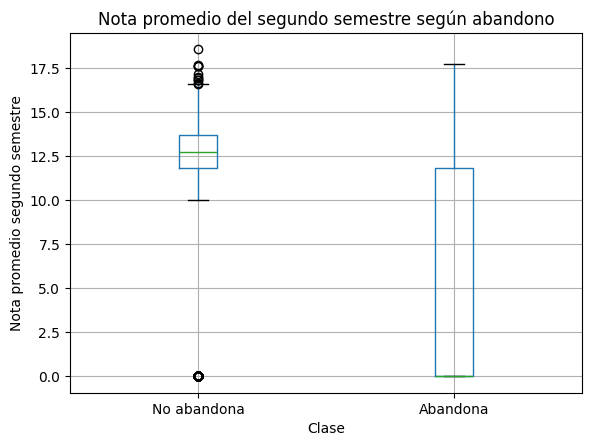

In [ ]:
columna = "Curricular units 2nd sem (grade)"

if columna in df.columns:
    plt.figure(figsize=(6,4))
    df.boxplot(column=columna, by="Dropout_Binary")

    plt.title("Nota promedio del segundo semestre según abandono")
    plt.suptitle("")
    plt.xlabel("Clase")
    plt.ylabel("Nota promedio segundo semestre")
    plt.xticks(ticks=[1, 2], labels=["No abandona", "Abandona"])
    plt.show()
else:
    print("La columna no existe con ese nombre.")

In [ ]:
# Calcular correlación de cada variable numérica con Dropout_Binary
correlaciones = df.drop(columns=["Target"]).corr(numeric_only=True)["Dropout_Binary"].sort_values(ascending=False)

correlaciones.head(15)

,Dropout_Binary
Dropout_Binary,1.000000
Age at enrollment,0.254215
Debtor,0.229407
Gender,0.203983
Application mode,0.198458
Marital Status,0.093712
Curricular units 2nd sem (without evaluations),0.079901
Mother's qualification,0.064958
Curricular units 1st sem (without evaluations),0.054230
Previous qualification,0.049379


In [ ]:
correlaciones.tail(15)

,Dropout_Binary
Application order,-0.070485
Previous qualification (grade),-0.078208
Daytime/evening attendance,-0.080499
Curricular units 1st sem (evaluations),-0.090125
Admission grade,-0.095806
Displaced,-0.107232
Curricular units 1st sem (enrolled),-0.124635
Curricular units 2nd sem (enrolled),-0.141515
Curricular units 2nd sem (evaluations),-0.154999
Scholarship holder,-0.245354


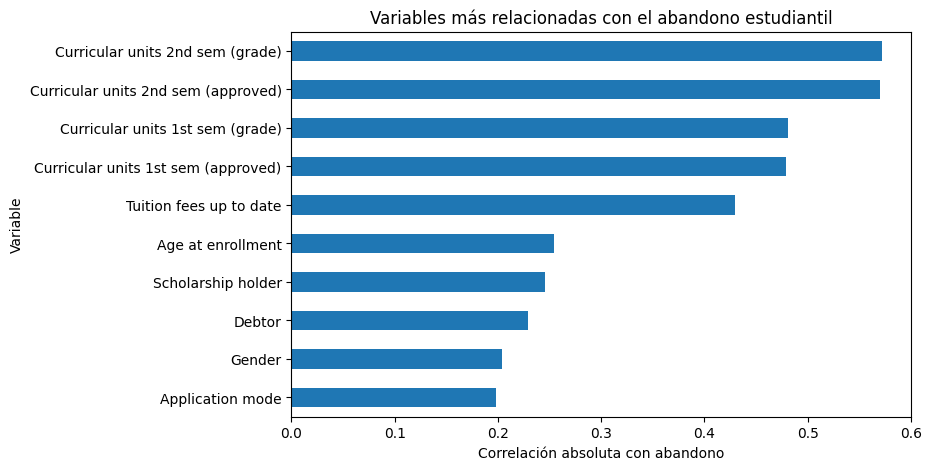

In [ ]:
# Tomar las 10 variables con mayor correlación absoluta con abandono
top_corr = correlaciones.drop("Dropout_Binary").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_corr.sort_values().plot(kind="barh")

plt.title("Variables más relacionadas con el abandono estudiantil")
plt.xlabel("Correlación absoluta con abandono")
plt.ylabel("Variable")
plt.show()

### Variables asociadas al abandono

A partir del análisis exploratorio se identificaron variables académicas y administrativas relacionadas con el abandono estudiantil. En particular, variables como el rendimiento académico en unidades curriculares, el número de asignaturas aprobadas, la situación de deuda y el estado de pago de matrícula muestran diferencias entre estudiantes que abandonan y estudiantes que continúan o se gradúan.

Este resultado sugiere que el abandono estudiantil no depende de una sola variable, sino de una combinación de factores académicos, económicos y personales. Por esta razón, se justifica el uso de modelos de Machine Learning capaces de capturar relaciones entre múltiples variables.

In [ ]:
df.groupby("Dropout_Binary")[columnas_interes].mean().T

Dropout_Binary,0,1
Admission grade,127.932434,124.961365
Previous qualification (grade),133.322744,131.114075
Curricular units 1st sem (approved),5.726274,2.551724
Curricular units 1st sem (grade),12.242187,7.256656
Curricular units 2nd sem (approved),5.616717,1.940183
Curricular units 2nd sem (grade),12.279544,5.899339
Age at enrollment,21.938395,26.068966
Tuition fees up to date,0.976357,0.678395
Debtor,0.063603,0.219564
Scholarship holder,0.321345,0.094300


In [ ]:
correlaciones.head(15)

,Dropout_Binary
Dropout_Binary,1.000000
Age at enrollment,0.254215
Debtor,0.229407
Gender,0.203983
Application mode,0.198458
Marital Status,0.093712
Curricular units 2nd sem (without evaluations),0.079901
Mother's qualification,0.064958
Curricular units 1st sem (without evaluations),0.054230
Previous qualification,0.049379


### Análisis de variables académicas y económicas

Al comparar los promedios entre estudiantes que abandonan y estudiantes que no abandonan, se observan diferencias importantes. Los estudiantes que abandonan presentan menor número de unidades curriculares aprobadas tanto en el primer como en el segundo semestre. También tienen calificaciones promedio más bajas, especialmente en el segundo semestre.

Además, los estudiantes que abandonan tienen mayor edad promedio al momento de matricularse y una mayor proporción de deuda. Por otro lado, los estudiantes que no abandonan presentan una mayor proporción de matrícula al día y de becas.

Estos hallazgos sugieren que el abandono estudiantil está relacionado principalmente con factores académicos y económicos. Por esta razón, variables como rendimiento, número de materias aprobadas, deuda y estado de matrícula serán relevantes para el modelo predictivo.

In [ ]:
correlaciones.tail(15)

,Dropout_Binary
Application order,-0.070485
Previous qualification (grade),-0.078208
Daytime/evening attendance,-0.080499
Curricular units 1st sem (evaluations),-0.090125
Admission grade,-0.095806
Displaced,-0.107232
Curricular units 1st sem (enrolled),-0.124635
Curricular units 2nd sem (enrolled),-0.141515
Curricular units 2nd sem (evaluations),-0.154999
Scholarship holder,-0.245354


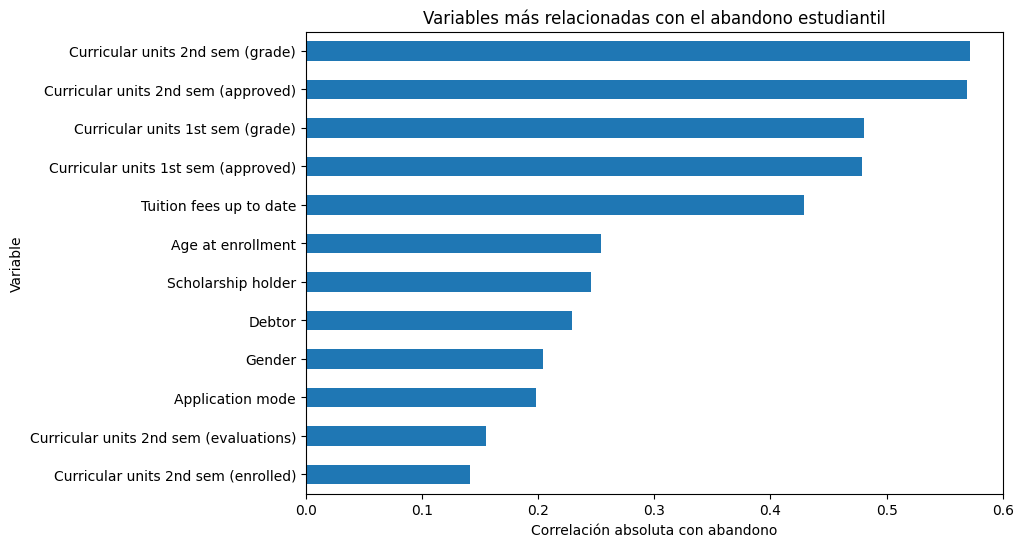

In [ ]:
# Variables más relacionadas con abandono, tanto positiva como negativamente
top_corr_completo = correlaciones.drop("Dropout_Binary").abs().sort_values(ascending=False).head(12)

plt.figure(figsize=(9,6))
top_corr_completo.sort_values().plot(kind="barh")

plt.title("Variables más relacionadas con el abandono estudiantil")
plt.xlabel("Correlación absoluta con abandono")
plt.ylabel("Variable")
plt.show()

<Figure size 600x400 with 0 Axes>

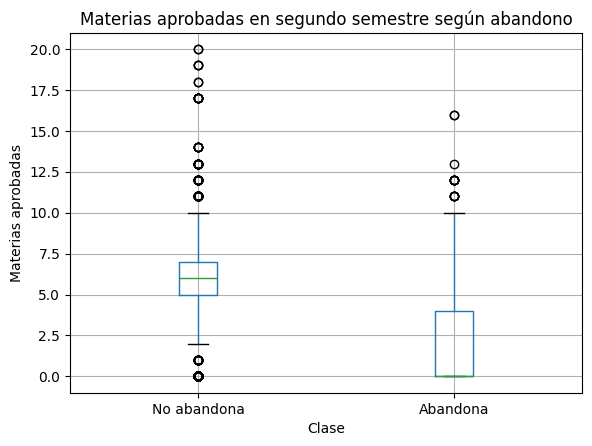

In [ ]:
columna = "Curricular units 2nd sem (approved)"

plt.figure(figsize=(6,4))
df.boxplot(column=columna, by="Dropout_Binary")

plt.title("Materias aprobadas en segundo semestre según abandono")
plt.suptitle("")
plt.xlabel("Clase")
plt.ylabel("Materias aprobadas")
plt.xticks(ticks=[1, 2], labels=["No abandona", "Abandona"])
plt.show()

<Figure size 600x400 with 0 Axes>

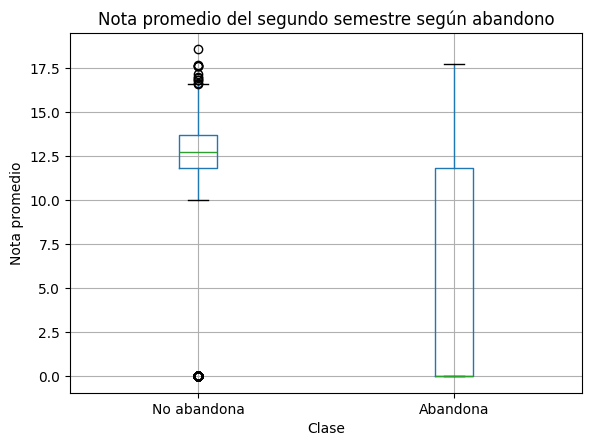

In [ ]:
columna = "Curricular units 2nd sem (grade)"

plt.figure(figsize=(6,4))
df.boxplot(column=columna, by="Dropout_Binary")

plt.title("Nota promedio del segundo semestre según abandono")
plt.suptitle("")
plt.xlabel("Clase")
plt.ylabel("Nota promedio")
plt.xticks(ticks=[1, 2], labels=["No abandona", "Abandona"])
plt.show()

### Hallazgos principales del EDA

El análisis de correlación muestra que las variables académicas son las más relacionadas con el abandono estudiantil. En particular, la nota promedio del segundo semestre y el número de unidades curriculares aprobadas en el segundo semestre presentan las correlaciones más fuertes con la variable objetivo.

Las correlaciones negativas indican que, a mayor rendimiento académico, menor es la probabilidad de abandono. Esto se observa especialmente en variables como `Curricular units 2nd sem (grade)`, `Curricular units 2nd sem (approved)`, `Curricular units 1st sem (grade)` y `Curricular units 1st sem (approved)`.

También se observa que variables económicas y administrativas influyen en el abandono. Por ejemplo, estar al día con el pago de matrícula se relaciona con menor abandono, mientras que ser deudor se relaciona con mayor riesgo. Además, la edad de ingreso muestra una relación positiva con el abandono, lo que sugiere que estudiantes que ingresan con mayor edad pueden presentar mayor riesgo de abandonar.

En general, el EDA evidencia que el abandono estudiantil depende de una combinación de factores académicos, económicos y personales.

In [ ]:
# ================================
# BLOQUE 3: PREPROCESAMIENTO
# ================================

# Variable objetivo
y = df["Dropout_Binary"]

# Variables predictoras
# Quitamos Target porque es la variable original
# Quitamos Dropout_Binary porque es la respuesta que queremos predecir
X = df.drop(columns=["Target", "Dropout_Binary"])

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (4424, 36)
Tamaño de y: (4424,)


In [ ]:
from sklearn.model_selection import train_test_split

# División 80% entrenamiento y 20% prueba
# stratify=y mantiene la misma proporción de abandono en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3539, 36)
X_test: (885, 36)
y_train: (3539,)
y_test: (885,)


In [ ]:
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)

Distribución en entrenamiento:
Dropout_Binary
0    67.87228
1    32.12772
Name: proportion, dtype: float64

Distribución en prueba:
Dropout_Binary
0    67.909605
1    32.090395
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    """
    Evalúa un modelo de clasificación binaria.
    Retorna un diccionario con las métricas principales.
    """

    y_pred = modelo.predict(X_test)

    # Algunos modelos tienen predict_proba, otros no
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC_ROC": auc
    }

    print("="*50)
    print(nombre_modelo)
    print("="*50)
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    return resultados

In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent", random_state=42)

baseline.fit(X_train, y_train)

resultado_baseline = evaluar_modelo(
    "Baseline - Clase mayoritaria",
    baseline,
    X_test,
    y_test
)

resultado_baseline

Baseline - Clase mayoritaria
Matriz de confusión:
[[601   0]
 [284   0]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       601
           1       0.00      0.00      0.00       284

    accuracy                           0.68       885
   macro avg       0.34      0.50      0.40       885
weighted avg       0.46      0.68      0.55       885



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

{'Modelo': 'Baseline - Clase mayoritaria',
 'Accuracy': 0.6790960451977401,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'AUC_ROC': np.float64(0.5)}

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)

resultado_logistico = evaluar_modelo(
    "Regresión Logística",
    modelo_logistico,
    X_test,
    y_test
)

resultado_logistico

Regresión Logística
Matriz de confusión:
[[575  26]
 [ 75 209]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.89      0.74      0.81       284

    accuracy                           0.89       885
   macro avg       0.89      0.85      0.86       885
weighted avg       0.89      0.89      0.88       885



{'Modelo': 'Regresión Logística',
 'Accuracy': 0.8858757062146893,
 'Precision': 0.8893617021276595,
 'Recall': 0.7359154929577465,
 'F1': 0.8053949903660886,
 'AUC_ROC': np.float64(0.9266070633451289)}

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

resultado_rf = evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_test,
    y_test
)

resultado_rf

Random Forest
Matriz de confusión:
[[573  28]
 [ 74 210]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       601
           1       0.88      0.74      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



{'Modelo': 'Random Forest',
 'Accuracy': 0.8847457627118644,
 'Precision': 0.8823529411764706,
 'Recall': 0.7394366197183099,
 'F1': 0.8045977011494253,
 'AUC_ROC': np.float64(0.9316338965573808)}

In [ ]:
resultados = pd.DataFrame([
    resultado_baseline,
    resultado_logistico,
    resultado_rf
])

resultados

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,Baseline - Clase mayoritaria,0.679096,0.000000,0.000000,0.000000,0.500000
1,Regresión Logística,0.885876,0.889362,0.735915,0.805395,0.926607
2,Random Forest,0.884746,0.882353,0.739437,0.804598,0.931634


In [ ]:
resultados.sort_values(by="F1", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
1,Regresión Logística,0.885876,0.889362,0.735915,0.805395,0.926607
2,Random Forest,0.884746,0.882353,0.739437,0.804598,0.931634
0,Baseline - Clase mayoritaria,0.679096,0.000000,0.000000,0.000000,0.500000


El modelo Random Forest fue seleccionado como modelo principal debido a que obtuvo el mayor AUC-ROC y el mayor recall entre los modelos evaluados. Aunque la Regresión Logística obtuvo un F1-score ligeramente superior, la diferencia fue mínima. En el contexto del abandono estudiantil, se prioriza la capacidad del modelo para identificar correctamente estudiantes en riesgo, por lo que el recall y el AUC-ROC son métricas especialmente relevantes.

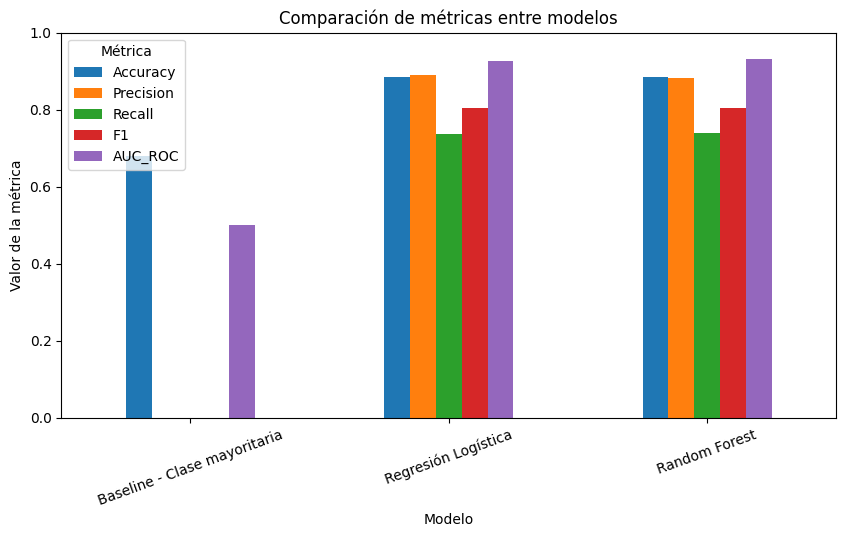

In [ ]:
# ================================
# BLOQUE 4: VISUALIZACIÓN DE RESULTADOS
# ================================

metricas = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC"]

resultados_plot = resultados.set_index("Modelo")[metricas]

resultados_plot.plot(kind="bar", figsize=(10,5))

plt.title("Comparación de métricas entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Métrica")
plt.show()

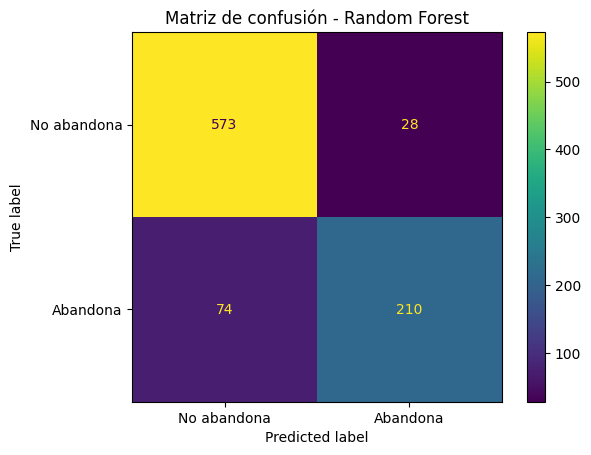

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Predicciones del modelo principal
y_pred_rf = modelo_rf.predict(X_test)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No abandona", "Abandona"]
)

plt.title("Matriz de confusión - Random Forest")
plt.show()

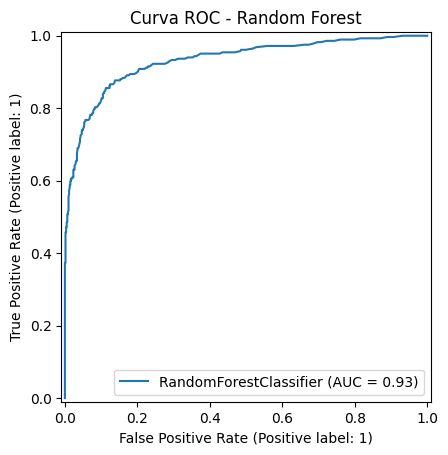

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    modelo_rf,
    X_test,
    y_test
)

plt.title("Curva ROC - Random Forest")
plt.show()

In [ ]:
# Importancia de variables del Random Forest
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(15)

,Variable,Importancia
30,Curricular units 2nd sem (approved),0.159142
31,Curricular units 2nd sem (grade),0.111031
24,Curricular units 1st sem (approved),0.097892
25,Curricular units 1st sem (grade),0.067260
16,Tuition fees up to date,0.054585
19,Age at enrollment,0.040383
12,Admission grade,0.038214
29,Curricular units 2nd sem (evaluations),0.034175
6,Previous qualification (grade),0.033995
3,Course,0.029661


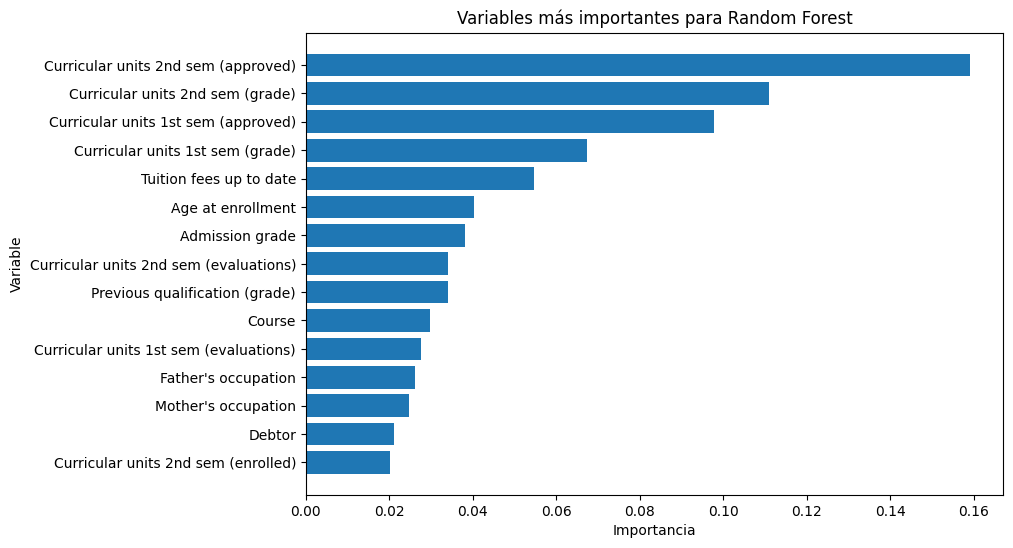

In [ ]:
top_importancias = importancias.head(15).sort_values(by="Importancia")

plt.figure(figsize=(9,6))
plt.barh(top_importancias["Variable"], top_importancias["Importancia"])

plt.title("Variables más importantes para Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### Evaluación de modelos

Se evaluaron tres modelos: un baseline basado en la clase mayoritaria, una Regresión Logística y un Random Forest. El baseline obtuvo un accuracy de 0.6791, pero su F1-score y recall fueron 0. Esto indica que el modelo no es capaz de identificar estudiantes que abandonan, ya que siempre predice la clase mayoritaria.

Los modelos de Machine Learning superaron ampliamente al baseline. La Regresión Logística obtuvo un F1-score de 0.8054, mientras que Random Forest obtuvo un F1-score de 0.8046. Aunque la diferencia entre ambos modelos es pequeña, Random Forest alcanzó el mayor AUC-ROC, con un valor de 0.9316, y un recall ligeramente superior.

Debido a que el objetivo del proyecto es identificar estudiantes en riesgo de abandono, se selecciona Random Forest como modelo principal. En este contexto, es importante priorizar la capacidad del modelo para detectar correctamente los casos de abandono, ya que estos estudiantes podrían recibir estrategias de intervención temprana.

### Interpretación de la matriz de confusión

La matriz de confusión del modelo Random Forest muestra que el sistema clasificó correctamente 573 estudiantes que no abandonan y 210 estudiantes que sí abandonan. También se observan 28 falsos positivos, es decir, estudiantes que el modelo clasificó como riesgo de abandono aunque realmente no abandonaron, y 74 falsos negativos, que corresponden a estudiantes que sí abandonaron pero el modelo no logró detectar.

En el contexto del abandono estudiantil, los falsos negativos son especialmente importantes, ya que representan estudiantes en riesgo que no serían identificados para recibir apoyo. Aun así, el modelo logra detectar una proporción considerable de los casos de abandono, con un recall de aproximadamente 0.7394 y un AUC-ROC de 0.9316.

### Importancia de variables

El análisis de importancia de variables del Random Forest muestra que los factores académicos son los más relevantes para predecir el abandono estudiantil. Las variables con mayor importancia corresponden al número de unidades curriculares aprobadas y a las calificaciones promedio del primer y segundo semestre.

También aparecen variables económicas y administrativas, como el estado de pago de matrícula (`Tuition fees up to date`) y si el estudiante es deudor (`Debtor`). Esto confirma los hallazgos del EDA, donde se observó que el abandono no depende únicamente del rendimiento académico, sino también de condiciones económicas y personales.

Estos resultados permiten justificar el uso del modelo como una herramienta de apoyo para detectar estudiantes en riesgo y generar recomendaciones de intervención temprana.

In [ ]:
# ================================
# BLOQUE 5: SISTEMA DE RECOMENDACIÓN
# ================================

def predecir_estudiante(indice):
    """
    Recibe el índice de un estudiante del conjunto de prueba.
    Retorna la predicción, probabilidad y datos principales.
    """

    estudiante = X_test.iloc[[indice]]

    prediccion = modelo_rf.predict(estudiante)[0]
    probabilidad = modelo_rf.predict_proba(estudiante)[0][1]

    resultado = {
        "indice": indice,
        "prediccion": prediccion,
        "probabilidad_abandono": probabilidad
    }

    return estudiante, resultado

In [ ]:
estudiante, resultado = predecir_estudiante(0)

print("Predicción:", resultado["prediccion"])
print("Probabilidad de abandono:", resultado["probabilidad_abandono"])

Predicción: 0
Probabilidad de abandono: 0.06666666666666667


In [ ]:
def clasificar_riesgo(probabilidad):
    """
    Clasifica el nivel de riesgo según la probabilidad de abandono.
    """

    if probabilidad >= 0.70:
        return "Alto"
    elif probabilidad >= 0.40:
        return "Medio"
    else:
        return "Bajo"

In [ ]:
riesgo = clasificar_riesgo(resultado["probabilidad_abandono"])

print("Probabilidad:", resultado["probabilidad_abandono"])
print("Nivel de riesgo:", riesgo)

Probabilidad: 0.06666666666666667
Nivel de riesgo: Bajo


In [ ]:
estudiante, resultado = predecir_estudiante(0)

recomendacion = generar_recomendacion(
    estudiante,
    resultado["probabilidad_abandono"]
)

print(recomendacion)

NameError: name 'generar_recomendacion' is not defined

In [ ]:
# Calcular probabilidades de abandono para todo el conjunto de prueba
probabilidades_test = modelo_rf.predict_proba(X_test)[:, 1]

# Crear tabla con probabilidades
casos_riesgo = pd.DataFrame({
    "indice": range(len(X_test)),
    "probabilidad_abandono": probabilidades_test,
    "real": y_test.values
})

# Ordenar de mayor a menor riesgo
casos_riesgo = casos_riesgo.sort_values(by="probabilidad_abandono", ascending=False)

casos_riesgo.head(10)

,indice,probabilidad_abandono,real
759,759,1.000000,1
505,505,0.996667,1
341,341,0.996667,1
83,83,0.996667,1
553,553,0.993333,1
9,9,0.993333,1
368,368,0.990000,1
77,77,0.990000,1
770,770,0.986667,1
271,271,0.986667,1


In [ ]:
indice_alto_riesgo = int(casos_riesgo.iloc[0]["indice"])

estudiante, resultado = predecir_estudiante(indice_alto_riesgo)

print("Índice:", indice_alto_riesgo)
print("Predicción:", resultado["prediccion"])
print("Probabilidad de abandono:", resultado["probabilidad_abandono"])

print(generar_recomendacion(estudiante, resultado["probabilidad_abandono"]))

NameError: name 'casos_riesgo' is not defined

### Sistema de recomendación personalizada

Además del modelo predictivo, se implementó un módulo de recomendación automática. Este módulo toma como entrada la probabilidad de abandono estimada por el modelo y algunas variables relevantes del estudiante, como rendimiento académico, número de materias aprobadas, estado de matrícula, deuda y edad de ingreso.

Con esta información, el sistema genera una recomendación personalizada orientada a la intervención temprana. Por ejemplo, si el estudiante presenta bajo rendimiento académico, se sugiere acompañamiento mediante tutorías o monitorías. Si el estudiante tiene deuda o no está al día con la matrícula, se recomienda remitir el caso a apoyo financiero.

Este componente permite que la salida del modelo no sea solo una predicción numérica, sino una recomendación interpretable y accionable para apoyar la toma de decisiones académicas.

In [ ]:
def resumir_estudiante_para_llm(estudiante, probabilidad):
    """
    Crea un resumen estructurado del estudiante para enviarlo al LLM.
    """

    datos = estudiante.iloc[0]
    riesgo = clasificar_riesgo(probabilidad)

    resumen = {
        "nivel_riesgo": riesgo,
        "probabilidad_abandono": round(probabilidad * 100, 2),
        "materias_aprobadas_1er_sem": datos.get("Curricular units 1st sem (approved)", "No disponible"),
        "nota_1er_sem": datos.get("Curricular units 1st sem (grade)", "No disponible"),
        "materias_aprobadas_2do_sem": datos.get("Curricular units 2nd sem (approved)", "No disponible"),
        "nota_2do_sem": datos.get("Curricular units 2nd sem (grade)", "No disponible"),
        "matricula_al_dia": datos.get("Tuition fees up to date", "No disponible"),
        "deudor": datos.get("Debtor", "No disponible"),
        "becario": datos.get("Scholarship holder", "No disponible"),
        "edad_ingreso": datos.get("Age at enrollment", "No disponible")
    }

    return resumen

In [ ]:
def crear_prompt_llm(resumen):
    """
    Crea el prompt que se enviaría al modelo de lenguaje.
    """

    prompt = f"""
Actúa como un asistente académico universitario.

Tu tarea es generar una recomendación personalizada para un estudiante,
basada en la predicción de riesgo de abandono realizada por un modelo de Machine Learning.

Datos del estudiante:
- Nivel de riesgo: {resumen["nivel_riesgo"]}
- Probabilidad estimada de abandono: {resumen["probabilidad_abandono"]}%
- Materias aprobadas en primer semestre: {resumen["materias_aprobadas_1er_sem"]}
- Nota promedio primer semestre: {resumen["nota_1er_sem"]}
- Materias aprobadas en segundo semestre: {resumen["materias_aprobadas_2do_sem"]}
- Nota promedio segundo semestre: {resumen["nota_2do_sem"]}
- Matrícula al día: {resumen["matricula_al_dia"]}
- Deudor: {resumen["deudor"]}
- Becario: {resumen["becario"]}
- Edad de ingreso: {resumen["edad_ingreso"]}

Genera una recomendación breve, clara y accionable.
No inventes información.
No des diagnósticos personales.
Enfócate en apoyo académico, seguimiento institucional, apoyo financiero si aplica y acompañamiento preventivo.

Respuesta esperada:
1. Nivel de riesgo.
2. Explicación breve.
3. Recomendaciones concretas.
"""

    return prompt

In [ ]:
indice_alto_riesgo = int(casos_riesgo.iloc[0]["indice"])

estudiante, resultado = predecir_estudiante(indice_alto_riesgo)

resumen = resumir_estudiante_para_llm(
    estudiante,
    resultado["probabilidad_abandono"]
)

prompt_llm = crear_prompt_llm(resumen)

print(prompt_llm)

In [ ]:
def respuesta_llm_demo(resumen):
    """
    Simula una respuesta tipo LLM usando el resumen del estudiante.
    Esta función permite mostrar el flujo completo sin depender de una API externa.
    """

    riesgo = resumen["nivel_riesgo"]
    prob = resumen["probabilidad_abandono"]

    respuesta = f"""
Nivel de riesgo: {riesgo}

El modelo identifica una probabilidad estimada de abandono del {prob}%.
Este resultado indica que el estudiante requiere seguimiento institucional, especialmente en factores académicos y de permanencia.

Recomendaciones concretas:
"""

    if resumen["materias_aprobadas_2do_sem"] != "No disponible" and resumen["materias_aprobadas_2do_sem"] < 3:
        respuesta += "\n- Asignar tutorías académicas para reforzar las asignaturas con bajo desempeño."

    if resumen["nota_2do_sem"] != "No disponible" and resumen["nota_2do_sem"] < 10:
        respuesta += "\n- Realizar seguimiento al rendimiento académico del segundo semestre."

    if resumen["matricula_al_dia"] == 0 or resumen["deudor"] == 1:
        respuesta += "\n- Remitir el caso a bienestar universitario o apoyo financiero."

    if resumen["edad_ingreso"] != "No disponible" and resumen["edad_ingreso"] > 25:
        respuesta += "\n- Ofrecer acompañamiento flexible considerando posibles responsabilidades laborales o familiares."

    respuesta += "\n- Programar una revisión periódica del caso para verificar si el riesgo disminuye."

    return respuesta

In [ ]:
respuesta = respuesta_llm_demo(resumen)

print(respuesta)

### Componente LLM para recomendaciones

El sistema incorpora un componente basado en LLM para transformar la salida del modelo predictivo en una recomendación comprensible y accionable. Primero, el modelo Random Forest estima la probabilidad de abandono del estudiante. Luego, se extraen variables relevantes como rendimiento académico, materias aprobadas, estado de matrícula, deuda, beca y edad de ingreso.

Con esta información se construye un prompt estructurado que permite al LLM generar una recomendación personalizada. Este componente mejora la interpretabilidad del sistema, ya que convierte una predicción numérica en una orientación práctica para posibles intervenciones académicas, financieras o institucionales.

In [ ]:
!pip install joblib

In [ ]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [ ]:
import joblib

# Guardar modelo entrenado
joblib.dump(modelo_rf, "models/modelo_random_forest.pkl")

# Guardar columnas usadas por el modelo
joblib.dump(list(X.columns), "models/columnas_modelo.pkl")

print("Modelo y columnas guardados correctamente.")

In [ ]:
# Guardar dataset procesado para usarlo en la app
df.to_csv("data/student_dropout_procesado.csv", index=False)

print("Dataset guardado correctamente.")

In [ ]:
modelo_cargado = joblib.load("models/modelo_random_forest.pkl")
columnas_cargadas = joblib.load("models/columnas_modelo.pkl")

print("Modelo cargado correctamente.")
print("Número de columnas:", len(columnas_cargadas))

In [ ]:
# Tomamos un estudiante de prueba
estudiante_prueba = X_test.iloc[[0]]

pred = modelo_cargado.predict(estudiante_prueba)[0]
prob = modelo_cargado.predict_proba(estudiante_prueba)[0][1]

print("Predicción:", pred)
print("Probabilidad de abandono:", prob)

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# ================================
# CONFIGURACIÓN DE LA APP
# ================================

st.set_page_config(
    page_title="Predicción de Abandono Estudiantil",
    page_icon="🎓",
    layout="wide"
)

# ================================
# CARGA DE MODELO Y DATOS
# ================================

@st.cache_resource
def cargar_modelo():
    modelo = joblib.load("models/modelo_random_forest.pkl")
    columnas = joblib.load("models/columnas_modelo.pkl")
    return modelo, columnas

@st.cache_data
def cargar_datos():
    df = pd.read_csv("data/student_dropout_procesado.csv")
    return df

modelo, columnas_modelo = cargar_modelo()
df = cargar_datos()

# ================================
# FUNCIONES AUXILIARES
# ================================

def clasificar_riesgo(probabilidad):
    if probabilidad >= 0.70:
        return "Alto"
    elif probabilidad >= 0.40:
        return "Medio"
    else:
        return "Bajo"


def resumir_estudiante_para_llm(estudiante, probabilidad):
    datos = estudiante.iloc[0]
    riesgo = clasificar_riesgo(probabilidad)

    resumen = {
        "nivel_riesgo": riesgo,
        "probabilidad_abandono": round(probabilidad * 100, 2),
        "materias_aprobadas_1er_sem": datos.get("Curricular units 1st sem (approved)", "No disponible"),
        "nota_1er_sem": datos.get("Curricular units 1st sem (grade)", "No disponible"),
        "materias_aprobadas_2do_sem": datos.get("Curricular units 2nd sem (approved)", "No disponible"),
        "nota_2do_sem": datos.get("Curricular units 2nd sem (grade)", "No disponible"),
        "matricula_al_dia": datos.get("Tuition fees up to date", "No disponible"),
        "deudor": datos.get("Debtor", "No disponible"),
        "becario": datos.get("Scholarship holder", "No disponible"),
        "edad_ingreso": datos.get("Age at enrollment", "No disponible")
    }

    return resumen


def respuesta_llm_demo(resumen):
    riesgo = resumen["nivel_riesgo"]
    prob = resumen["probabilidad_abandono"]

    respuesta = f"""
**Nivel de riesgo:** {riesgo}

El modelo identifica una probabilidad estimada de abandono del **{prob}%**.
Este resultado indica que el estudiante requiere seguimiento institucional, especialmente en factores académicos y de permanencia.

**Recomendaciones concretas:**
"""

    if resumen["materias_aprobadas_2do_sem"] != "No disponible" and resumen["materias_aprobadas_2do_sem"] < 3:
        respuesta += "\n- Asignar tutorías académicas para reforzar las asignaturas con bajo desempeño."

    if resumen["nota_2do_sem"] != "No disponible" and resumen["nota_2do_sem"] < 10:
        respuesta += "\n- Realizar seguimiento al rendimiento académico del segundo semestre."

    if resumen["matricula_al_dia"] == 0 or resumen["deudor"] == 1:
        respuesta += "\n- Remitir el caso a bienestar universitario o apoyo financiero."

    if resumen["edad_ingreso"] != "No disponible" and resumen["edad_ingreso"] > 25:
        respuesta += "\n- Ofrecer acompañamiento flexible considerando posibles responsabilidades laborales o familiares."

    respuesta += "\n- Programar una revisión periódica del caso para verificar si el riesgo disminuye."

    return respuesta


# ================================
# INTERFAZ
# ================================

st.title("🎓 Sistema de Predicción de Abandono Estudiantil")
st.write(
    "Esta aplicación utiliza un modelo de Machine Learning para estimar el riesgo de abandono "
    "de un estudiante y generar una recomendación personalizada de intervención."
)

st.divider()

# Quitamos columnas objetivo si existen
df_modelo = df.drop(columns=["Target", "Dropout_Binary"], errors="ignore")

st.sidebar.header("Selección de estudiante")

indice = st.sidebar.number_input(
    "Selecciona el índice del estudiante",
    min_value=0,
    max_value=len(df_modelo) - 1,
    value=0,
    step=1
)

estudiante = df_modelo.iloc[[indice]]

st.subheader("Datos del estudiante seleccionado")
st.dataframe(estudiante)

if st.button("Predecir riesgo de abandono"):
    prediccion = modelo.predict(estudiante)[0]
    probabilidad = modelo.predict_proba(estudiante)[0][1]
    riesgo = clasificar_riesgo(probabilidad)

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Predicción", "Abandona" if prediccion == 1 else "No abandona")

    with col2:
        st.metric("Probabilidad de abandono", f"{probabilidad:.2%}")

    with col3:
        st.metric("Nivel de riesgo", riesgo)

    st.divider()

    st.subheader("Recomendación personalizada")

    resumen = resumir_estudiante_para_llm(estudiante, probabilidad)
    recomendacion = respuesta_llm_demo(resumen)

    st.markdown(recomendacion)

    st.info(
        "Nota: el modelo Random Forest realiza la predicción. "
        "El componente de recomendación transforma la predicción y las variables relevantes "
        "en una orientación comprensible para intervención académica."
    )

In [ ]:
!pip install pyngrok

In [ ]:
!ls

In [ ]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
streamlit
joblib
ucimlrepo

In [ ]:
!pkill -f streamlit || true

In [ ]:
!npm install -g localtunnel

In [ ]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

In [ ]:
!cat /content/logs.txt

In [ ]:
!pkill -f streamlit || true

In [ ]:
!streamlit run app.py --server.port 8501 --server.headless true &>/content/logs.txt &

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501, height=800)

In [ ]:
!tail -n 80 /content/logs.txt

In [ ]:
!pkill -f streamlit || true

In [ ]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  &>/content/logs.txt &

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

In [ ]:
# Buscar estudiantes de mayor riesgo en el dataset completo usado por la app

df_app = df.drop(columns=["Target", "Dropout_Binary"], errors="ignore")

probabilidades_app = modelo_rf.predict_proba(df_app)[:, 1]
predicciones_app = modelo_rf.predict(df_app)

casos_riesgo_app = pd.DataFrame({
    "indice_app": range(len(df_app)),
    "prediccion": predicciones_app,
    "probabilidad_abandono": probabilidades_app,
    "target_real": df["Target"].values,
    "dropout_real": df["Dropout_Binary"].values
})

casos_riesgo_app = casos_riesgo_app.sort_values(
    by="probabilidad_abandono",
    ascending=False
)

casos_riesgo_app.head(20)

### Demostración de la aplicación

La aplicación permite seleccionar un estudiante mediante su índice y aplicar el modelo Random Forest entrenado para estimar su riesgo de abandono. Para el estudiante con índice 959, el sistema predice la clase `Abandona`, con una probabilidad estimada de abandono del 100% y un nivel de riesgo alto.

Además de la predicción, el sistema genera una recomendación personalizada orientada a intervención temprana. En este caso, se sugieren tutorías académicas, seguimiento al rendimiento, posible apoyo financiero y revisión periódica del caso.

Esta funcionalidad permite transformar la salida del modelo en una herramienta más interpretable y útil para apoyar decisiones institucionales.

In [ ]:
%%writefile README.md
# Sistema de Predicción de Abandono Estudiantil con Machine Learning

## Descripción del proyecto

Este proyecto desarrolla un sistema de Inteligencia Artificial para predecir el riesgo de abandono estudiantil a partir de variables académicas, económicas y personales.

El modelo principal utilizado es un Random Forest, el cual estima la probabilidad de abandono de cada estudiante. Además, el sistema incluye un componente de recomendación personalizada que transforma la predicción del modelo en orientaciones accionables para intervención temprana.

## Dataset

Se utiliza el dataset **Predict Students' Dropout and Academic Success**, disponible en UCI Machine Learning Repository.

El dataset contiene información de estudiantes de educación superior y permite analizar tres estados académicos: graduado, matriculado y abandono. Para este proyecto, la variable objetivo se transformó en una clasificación binaria:

- 0: No abandona
- 1: Abandona

## Modelos evaluados

Se evaluaron tres modelos:

1. Baseline basado en clase mayoritaria.
2. Regresión Logística.
3. Random Forest.

## Resultados principales

| Modelo | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---|---:|---:|---:|---:|---:|
| Baseline | 0.6791 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |
| Regresión Logística | 0.8858 | 0.8894 | 0.7359 | 0.8054 | 0.9266 |
| Random Forest | 0.8847 | 0.8823 | 0.7394 | 0.8046 | 0.9316 |

El modelo Random Forest fue seleccionado como modelo principal debido a su buen desempeño general, especialmente en AUC-ROC y recall.

## Estructura del proyecto

```text
proyecto-final-ia/
├── app.py
├── README.md
├── requirements.txt
├── data/
│   └── student_dropout_procesado.csv
├── models/
│   ├── modelo_random_forest.pkl
│   └── columnas_modelo.pkl
└── notebooks/
    └── Proyecto_Final_IA_Abandono_Estudiantil.ipynb

Writing README.md


In [ ]:
pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
!pkill -f streamlit || true

In [ ]:
!pkill -f streamlit || true

In [ ]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  &>/content/logs.txt &

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

In [57]:
!zip -r proyecto_final_ia.zip app.py README.md requirements.txt data models Proyecto_Final_IA_Abandono_Estudiantil.ipynb

	zip warning: name not matched: app.py
	zip warning: name not matched: requirements.txt
	zip warning: name not matched: data
	zip warning: name not matched: models
	zip warning: name not matched: Proyecto_Final_IA_Abandono_Estudiantil.ipynb
  adding: README.md (deflated 50%)


In [58]:
!pwd
!ls -la

/content
total 28
drwxr-xr-x 1 root root 4096 May 19 22:03 .
drwxr-xr-x 1 root root 4096 May 19 21:03 ..
drwxr-xr-x 4 root root 4096 May 12 13:29 .config
-rw-r--r-- 1 root root   48 May 19 21:56 logs.txt
-rw-r--r-- 1 root root 1117 May 19 22:03 proyecto_final_ia.zip
-rw-r--r-- 1 root root 1903 May 19 21:58 README.md
drwxr-xr-x 1 root root 4096 May 12 13:29 sample_data


In [59]:
!find /content -maxdepth 3 -type f

/content/.config/default_configs.db
/content/.config/.last_update_check.json
/content/.config/.last_survey_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/gce
/content/.config/config_sentinel
/content/README.md
/content/proyecto_final_ia.zip
/content/logs.txt
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [60]:
print("modelo_rf existe:", "modelo_rf" in globals())
print("X existe:", "X" in globals())
print("df existe:", "df" in globals())

modelo_rf existe: True
X existe: True
df existe: True


In [61]:
import os
import joblib

# Crear carpetas
os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Guardar modelo y columnas
joblib.dump(modelo_rf, "models/modelo_random_forest.pkl")
joblib.dump(list(X.columns), "models/columnas_modelo.pkl")

# Guardar dataset procesado
df.to_csv("data/student_dropout_procesado.csv", index=False)

# Crear requirements.txt
with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write("""pandas
numpy
scikit-learn
matplotlib
streamlit
joblib
ucimlrepo
""")

# Crear app.py
app_code = r'''
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Predicción de Abandono Estudiantil",
    page_icon="🎓",
    layout="wide"
)

@st.cache_resource
def cargar_modelo():
    modelo = joblib.load("models/modelo_random_forest.pkl")
    columnas = joblib.load("models/columnas_modelo.pkl")
    return modelo, columnas

@st.cache_data
def cargar_datos():
    return pd.read_csv("data/student_dropout_procesado.csv")

modelo, columnas_modelo = cargar_modelo()
df = cargar_datos()

def clasificar_riesgo(probabilidad):
    if probabilidad >= 0.70:
        return "Alto"
    elif probabilidad >= 0.40:
        return "Medio"
    else:
        return "Bajo"

def resumir_estudiante_para_llm(estudiante, probabilidad):
    datos = estudiante.iloc[0]
    riesgo = clasificar_riesgo(probabilidad)

    resumen = {
        "nivel_riesgo": riesgo,
        "probabilidad_abandono": round(probabilidad * 100, 2),
        "materias_aprobadas_1er_sem": datos.get("Curricular units 1st sem (approved)", "No disponible"),
        "nota_1er_sem": datos.get("Curricular units 1st sem (grade)", "No disponible"),
        "materias_aprobadas_2do_sem": datos.get("Curricular units 2nd sem (approved)", "No disponible"),
        "nota_2do_sem": datos.get("Curricular units 2nd sem (grade)", "No disponible"),
        "matricula_al_dia": datos.get("Tuition fees up to date", "No disponible"),
        "deudor": datos.get("Debtor", "No disponible"),
        "becario": datos.get("Scholarship holder", "No disponible"),
        "edad_ingreso": datos.get("Age at enrollment", "No disponible")
    }

    return resumen

def respuesta_llm_demo(resumen):
    riesgo = resumen["nivel_riesgo"]
    prob = resumen["probabilidad_abandono"]

    respuesta = f"""
**Nivel de riesgo:** {riesgo}

El modelo identifica una probabilidad estimada de abandono del **{prob}%**.
Este resultado indica que el estudiante requiere seguimiento institucional, especialmente en factores académicos y de permanencia.

**Recomendaciones concretas:**
"""

    if resumen["materias_aprobadas_2do_sem"] != "No disponible" and resumen["materias_aprobadas_2do_sem"] < 3:
        respuesta += "\n- Asignar tutorías académicas para reforzar las asignaturas con bajo desempeño."

    if resumen["nota_2do_sem"] != "No disponible" and resumen["nota_2do_sem"] < 10:
        respuesta += "\n- Realizar seguimiento al rendimiento académico del segundo semestre."

    if resumen["matricula_al_dia"] == 0 or resumen["deudor"] == 1:
        respuesta += "\n- Remitir el caso a bienestar universitario o apoyo financiero."

    if resumen["edad_ingreso"] != "No disponible" and resumen["edad_ingreso"] > 25:
        respuesta += "\n- Ofrecer acompañamiento flexible considerando posibles responsabilidades laborales o familiares."

    respuesta += "\n- Programar una revisión periódica del caso para verificar si el riesgo disminuye."

    return respuesta

st.title("🎓 Sistema de Predicción de Abandono Estudiantil")

st.write(
    "Esta aplicación utiliza un modelo de Machine Learning para estimar el riesgo de abandono "
    "de un estudiante y generar una recomendación personalizada de intervención."
)

st.divider()

df_modelo = df.drop(columns=["Target", "Dropout_Binary"], errors="ignore")

st.sidebar.header("Selección de estudiante")

indice = st.sidebar.number_input(
    "Selecciona el índice del estudiante",
    min_value=0,
    max_value=len(df_modelo) - 1,
    value=0,
    step=1
)

estudiante = df_modelo.iloc[[indice]]

st.subheader("Datos del estudiante seleccionado")
st.dataframe(estudiante)

if st.button("Predecir riesgo de abandono"):
    prediccion = modelo.predict(estudiante)[0]
    probabilidad = modelo.predict_proba(estudiante)[0][1]
    riesgo = clasificar_riesgo(probabilidad)

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Predicción", "Abandona" if prediccion == 1 else "No abandona")

    with col2:
        st.metric("Probabilidad de abandono", f"{probabilidad:.2%}")

    with col3:
        st.metric("Nivel de riesgo", riesgo)

    st.divider()

    st.subheader("Recomendación personalizada")

    resumen = resumir_estudiante_para_llm(estudiante, probabilidad)
    recomendacion = respuesta_llm_demo(resumen)

    st.markdown(recomendacion)

    st.info(
        "Nota: el modelo Random Forest realiza la predicción. "
        "El componente de recomendación transforma la predicción y las variables relevantes "
        "en una orientación comprensible para intervención académica."
    )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Listo. Archivos recreados correctamente.")

Listo. Archivos recreados correctamente.


In [62]:
!ls -la
!ls models
!ls data

total 48
drwxr-xr-x 1 root root 4096 May 19 22:08 .
drwxr-xr-x 1 root root 4096 May 19 21:03 ..
-rw-r--r-- 1 root root 4563 May 19 22:08 app.py
drwxr-xr-x 4 root root 4096 May 12 13:29 .config
drwxr-xr-x 2 root root 4096 May 19 22:08 data
-rw-r--r-- 1 root root   48 May 19 21:56 logs.txt
drwxr-xr-x 2 root root 4096 May 19 22:08 models
-rw-r--r-- 1 root root 1117 May 19 22:03 proyecto_final_ia.zip
-rw-r--r-- 1 root root 1903 May 19 21:58 README.md
-rw-r--r-- 1 root root   64 May 19 22:08 requirements.txt
drwxr-xr-x 1 root root 4096 May 12 13:29 sample_data
columnas_modelo.pkl  modelo_random_forest.pkl
student_dropout_procesado.csv


In [63]:
!rm -f proyecto_final_ia.zip
!zip -r proyecto_final_ia.zip app.py README.md requirements.txt data models

  adding: app.py (deflated 63%)
  adding: README.md (deflated 50%)
  adding: requirements.txt (deflated 9%)
  adding: data/ (stored 0%)
  adding: data/student_dropout_procesado.csv (deflated 81%)
  adding: models/ (stored 0%)
  adding: models/modelo_random_forest.pkl (deflated 76%)
  adding: models/columnas_modelo.pkl (deflated 59%)


In [64]:
!unzip -l proyecto_final_ia.zip

Archive:  proyecto_final_ia.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     4563  2026-05-19 22:08   app.py
     1903  2026-05-19 21:58   README.md
       64  2026-05-19 22:08   requirements.txt
        0  2026-05-19 22:08   data/
   516839  2026-05-19 22:08   data/student_dropout_procesado.csv
        0  2026-05-19 22:08   models/
 22342505  2026-05-19 22:08   models/modelo_random_forest.pkl
      956  2026-05-19 22:08   models/columnas_modelo.pkl
---------                     -------
 22866830                     8 files


In [65]:
from google.colab import files
files.download("proyecto_final_ia.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>